# AutoSupply-AI — Forecast Analytics

This notebook analyzes the final vehicle demand forecasts generated by the
AutoSupply-AI demand forecasting pipeline.

### Objectives
- Analyze total forecasted demand
- Analyze monthly demand trends
- Analyze demand by vehicle group
- Analyze demand by state
- Analyze state × vehicle group demand
- Identify peak-demand combinations
- Detect zero-demand forecasts
- Generate business-oriented insights
- Export analytics datasets for dashboard integration

In [1]:
# ============================================================
# AUTOSUPPLY-AI — FORECAST ANALYTICS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

# Final forecast generated by 05_demand_forecasting.ipynb
FORECAST_FILE = PROCESSED_DIR / "final_demand_forecast.csv"

print("Forecast file:")
print(FORECAST_FILE)

Forecast file:
..\data\processed\final_demand_forecast.csv


In [4]:
# ============================================================
# PROJECT PATHS
# ============================================================

from pathlib import Path

# Current notebook directory
NOTEBOOK_DIR = Path.cwd()

# Your final forecast CSV is inside the notebooks folder
FORECAST_FILE = NOTEBOOK_DIR / "final_demand_forecast.csv"

print("Current working directory:")
print(NOTEBOOK_DIR)

print("\nForecast file:")
print(FORECAST_FILE)

print("\nFile exists:", FORECAST_FILE.exists())

Current working directory:
f:\AutoSupply-AI\notebooks

Forecast file:
f:\AutoSupply-AI\notebooks\final_demand_forecast.csv

File exists: True


In [5]:
# ============================================================
# LOAD FINAL FORECAST DATASET
# ============================================================

forecast_df = pd.read_csv(FORECAST_FILE)

# Convert month to datetime
forecast_df["month"] = pd.to_datetime(forecast_df["month"])

print("=" * 70)
print("FINAL FORECAST DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print(f"Shape: {forecast_df.shape}")
print(f"Columns: {forecast_df.columns.tolist()}")
print(f"Date range: {forecast_df['month'].min()} to {forecast_df['month'].max()}")

display(forecast_df.head(10))

FINAL FORECAST DATASET LOADED SUCCESSFULLY
Shape: (1218, 4)
Columns: ['month', 'state', 'vehicle_group', 'predicted_demand']
Date range: 2024-05-01 00:00:00 to 2024-10-01 00:00:00


,month,state,vehicle_group,predicted_demand
0,2024-05-01,Andaman And Nicobar Islands,Goods Vehicle,369.93
1,2024-05-01,Andaman And Nicobar Islands,Other Motor Vehicle,93.61
2,2024-05-01,Andaman And Nicobar Islands,Passenger Transport,"1,152.34"
3,2024-05-01,Andaman And Nicobar Islands,Passenger Vehicle,369.93
4,2024-05-01,Andaman And Nicobar Islands,Three Wheeler,0.00
5,2024-05-01,Andaman And Nicobar Islands,Two Wheeler,"1,178.83"
6,2024-05-01,Andhra Pradesh,Goods Vehicle,"2,712.02"
7,2024-05-01,Andhra Pradesh,Other Motor Vehicle,"1,406.77"
8,2024-05-01,Andhra Pradesh,Passenger Transport,"1,406.77"
9,2024-05-01,Andhra Pradesh,Passenger Vehicle,"8,942.59"


In [6]:
# ============================================================
# FORECAST DATA VALIDATION
# ============================================================

print("=" * 70)
print("FORECAST DATA VALIDATION")
print("=" * 70)

# 1. Missing values
print("\n1. Missing Values:")
print(forecast_df.isnull().sum())

# 2. Duplicate rows
print("\n2. Duplicate Rows:")
print(forecast_df.duplicated().sum())

# 3. Negative predictions
print("\n3. Negative Predictions:")
print((forecast_df["predicted_demand"] < 0).sum())

# 4. Zero predictions
print("\n4. Zero Predictions:")
print((forecast_df["predicted_demand"] == 0).sum())

# 5. Unique states
print("\n5. Unique States:")
print(forecast_df["state"].nunique())

# 6. Unique vehicle groups
print("\n6. Unique Vehicle Groups:")
print(forecast_df["vehicle_group"].nunique())

# 7. Unique months
print("\n7. Forecast Months:")
print(forecast_df["month"].nunique())

# 8. Basic statistics
print("\n8. Prediction Statistics:")
display(
    forecast_df["predicted_demand"]
    .describe()
    .to_frame()
)

print("\n" + "=" * 70)
print("VALIDATION COMPLETE")
print("=" * 70)

FORECAST DATA VALIDATION

1. Missing Values:
month               0
state               0
vehicle_group       0
predicted_demand    0
dtype: int64

2. Duplicate Rows:
0

3. Negative Predictions:
0

4. Zero Predictions:
45

5. Unique States:
34

6. Unique Vehicle Groups:
6

7. Forecast Months:
6

8. Prediction Statistics:


,predicted_demand
count,"1,218.00"
mean,"21,970.86"
std,"118,102.58"
min,0.00
25%,289.71
50%,660.72
75%,"5,589.14"
max,"1,774,344.12"



VALIDATION COMPLETE


MONTHLY FORECAST ANALYSIS


,month,predicted_demand,month_name
0,2024-05-01,"4,259,327.10",May 2024
1,2024-06-01,"4,298,735.04",June 2024
2,2024-07-01,"4,285,073.25",July 2024
3,2024-08-01,"4,216,831.99",August 2024
4,2024-09-01,"4,818,792.86",September 2024
5,2024-10-01,"4,881,742.79",October 2024



Peak Forecast Month:
Month  : October 2024
Demand : 4,881,742.79

Lowest Forecast Month:
Month  : August 2024
Demand : 4,216,831.99


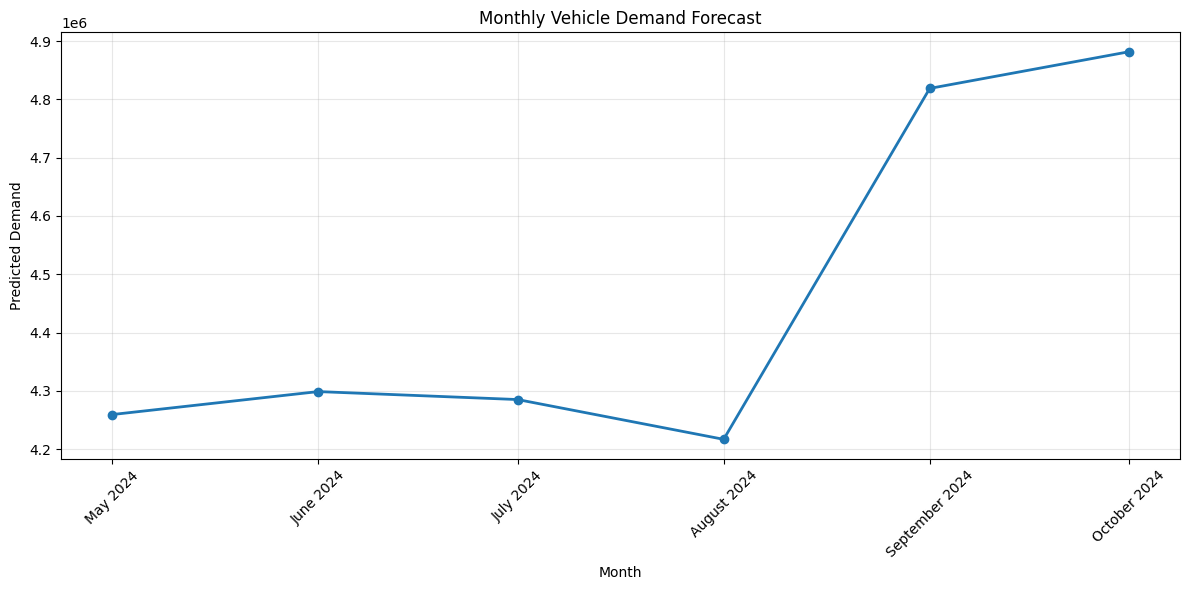

In [7]:
# ============================================================
# MONTHLY FORECAST ANALYSIS
# ============================================================

monthly_forecast = (
    forecast_df
    .groupby("month", as_index=False)["predicted_demand"]
    .sum()
    .sort_values("month")
)

# Add readable month name
monthly_forecast["month_name"] = (
    monthly_forecast["month"]
    .dt.strftime("%B %Y")
)

print("=" * 70)
print("MONTHLY FORECAST ANALYSIS")
print("=" * 70)

display(monthly_forecast)

# Key monthly metrics
peak_month = monthly_forecast.loc[
    monthly_forecast["predicted_demand"].idxmax()
]

lowest_month = monthly_forecast.loc[
    monthly_forecast["predicted_demand"].idxmin()
]

print("\nPeak Forecast Month:")
print(f"Month  : {peak_month['month_name']}")
print(f"Demand : {peak_month['predicted_demand']:,.2f}")

print("\nLowest Forecast Month:")
print(f"Month  : {lowest_month['month_name']}")
print(f"Demand : {lowest_month['predicted_demand']:,.2f}")

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_forecast["month"],
    monthly_forecast["predicted_demand"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Vehicle Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Demand")
plt.xticks(
    monthly_forecast["month"],
    monthly_forecast["month_name"],
    rotation=45
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()